# Fast and Sure-ious Quantum Process Tomography

Companion notebook for *Fast and Sure-ious Quantum Process Tomography*, A. Afham, S. Sen and M. Tomamichel.

A quantum channel $\Phi$ is estimated by running state tomography on copies of its Choi state $\rho = \mathfrak{C}(\Phi)$ and then repairing the estimate, which is a density matrix but not the Choi state of a channel: its input marginal is not maximally mixed. The paper shows that the folklore repair, the **partial normalization**

$$\mathrm{N}_{\mathsf A}(\hat\rho) \;=\; \tfrac{1}{d_{\mathsf A}}\,\bigl(\hat\rho_{\mathsf A}^{-1/2}\otimes I_{\mathsf B}\bigr)\,\hat\rho\,\bigl(\hat\rho_{\mathsf A}^{-1/2}\otimes I_{\mathsf B}\bigr),$$

is the *exact* projection onto the Choi states of channels in fidelity. It is a single congruence, it preserves the Choi rank, and it costs one $d_{\mathsf A}\times d_{\mathsf A}$ eigendecomposition, so any state-tomography algorithm with a fidelity guarantee lifts to process tomography at the cost of a constant factor in accuracy.


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

# On Colab, uncomment (set the URL to the published repository first):
# !git clone -q https://github.com/afhamash/fidelity_QPT.git && cd fidelity_QPT

from fpls import *          # noqa: F403  -- the algorithm
from fplsplots import (fig_headline, fig_hip_iterations,
                       fig_threshold_strategies, fig_spectra, fig_accuracy,
                       fig_channel_robustness, fig_fullrank_tradeoff,
                       table_head_to_head)
import numpy as np

# The paper's figure style: matplotlib's built-in ggplot, with only the output
# settings and the Computer Modern math font overridden (see fpls._STYLE).
# fplsplots applies it on import; the call here makes it explicit and lets you
# style your own plots the same way.
plt = use_style()


### Notation

| code | paper | meaning |
|---|---|---|
| `rho` | $\rho = \mathfrak{C}(\Phi)$ | Choi state of the unknown channel, trace one |
| `dA`, `dB`, `d` | $d_{\mathsf A}, d_{\mathsf B}, d_{\mathsf{AB}}$ | input, output and Choi dimensions |
| `rho_ls` | $\hat\rho_{\mathrm{LS}}$ | least-squares estimate: Hermitian, unit trace, indefinite |
| `rho_hat` | $\hat\rho$ | density estimate: the thresholded, PSD, unit-trace estimate |
| `bernstein_radius(d, N)` | $\beta_N$ | concentration radius of $\hat\rho_{\mathrm{LS}}$ at confidence $\delta = 0.05$ |
| `threshold_density_estimate(H, tau)` | Algorithm 3 | spectrum thresholded at $\tau$, trace restored |
| `kraus_from_eig(mu, vecs, dA, dB)` | proof of Theorem 5 | Kraus operators from the eigenpairs of a Choi state, $K_i = \sqrt{d_{\mathsf A}\mu_i}\,V_i^{\mathsf T}$ |
| `fidelity_projection(rho, dA)` | $\Pi_{\mathcal C}= \mathrm{N}_{\mathsf A}$ | the partial normalization, Theorem 1 |
| `normalise_kraus(Ks)` | Theorem 5 | the same projection on Kraus operators, $K_i \mapsto K_i R^{-1/2}$ |
| `choi_rank(rho)` | $\operatorname{rank}$ | eigenvalues above $10^{-10}$, the paper's cutoff |
| `paper_rng(...)` | | seeds the cached sweeps were drawn from |

### How this notebook is organized

1. **The estimator on one small instance** (two qubits per side, seconds). FPLS step by step on one channel: the rank it recovers, its accuracy as $N$ grows, the estimate returned as Kraus operators, and a check that the Kraus route of Theorem 5 and the dense formula of Theorem 1 agree.
2. **The figures, recomputed.** One cell per figure and table of the paper, in the paper's order. Each runs a small version live in seconds; the paper's parameters are given beside it, commented out, with their runtime.
3. **The implementation on a worked example.** Theorem 1 checked on an explicit two-qubit state: the library against the formula, the optimal value, the certificate from the proof, and the stability constants.

## 1. The estimator on one small instance

The headline channel: an equal mixture of the quantum Fourier transform with one Haar-random unitary on two qubits, so the Choi rank is exactly 2. On two qubits its nonzero Choi eigenvalues are about $0.76$ and $0.24$ (at the paper's four qubits, about $0.52$ and $0.48$); the smaller one, $\lambda_r$, sets the onset of exact rank recovery. Here $d_{\mathsf{AB}} = 16$.

In [2]:
nq = 2                                   # qubits per side
dA = dB = 2 ** nq
rho = rank_two_channel(nq, paper_rng(PAPER_SEED, 1))

lam = np.linalg.eigvalsh(rho)[::-1]      # Choi eigenvalues, descending

print(f"d_A = d_B = {dA},  d_AB = {dA * dB}")
print(f"true Choi rank                r       = {choi_rank(rho)}")
print(f"smallest nonzero eigenvalue   lambda_r = {lam[choi_rank(rho) - 1]:.4f}")
print(f"is a channel (PSD, trace 1, maximally mixed marginal): {is_channel(rho, dA)}")

d_A = d_B = 4,  d_AB = 16
true Choi rank                r       = 2
smallest nonzero eigenvalue   lambda_r = 0.2438
is a channel (PSD, trace 1, maximally mixed marginal): True


Now the protocol: simulate $N$ single-copy local Pauli measurements, form the least-squares estimate, threshold its spectrum at $\tau = \beta_N$, and apply the fidelity projection. The threshold sits **above** the noise -- that is what makes rank recovery provable -- and `noise` below is the realized $\|\hat\rho_{\mathrm{LS}} - \rho\|_\infty$, which the concentration bound says stays under $\beta_N$ with probability $1-\delta$.

In [3]:
print(f"{'N':>10} {'beta_N':>9} {'noise':>9} {'rank':>6} {'1 - F':>11} {'Kraus ops':>10} {'bytes':>8}")
for N in (10 ** 4, 10 ** 5, 10 ** 6, 10 ** 7, 10 ** 8):
    r = fpls(rho, N, paper_rng(PAPER_SEED, 7, N), dA=dA)
    print(f"{N:>10.0e} {r['beta_N']:9.4f} {r['noise']:9.4f} {r['rank']:>6} {r['infidelity']:11.3e} "
          f"{len(r['kraus']):>10} {r['bytes']:>8}")
print(f"{'':>49} dense d_AB x d_AB matrix: {16 * dA * dB * dA * dB:>8} bytes")

assert r["noise"] < r["beta_N"], "the realized noise left the concentration event"
assert r["rank"] == choi_rank(rho), "rank not recovered at the largest N"
assert r["infidelity"] < 1e-5, "infidelity too large at the largest N"
print("\nrank recovered and the estimate is accurate at the largest N")

         N    beta_N     noise   rank       1 - F  Kraus ops    bytes
     1e+04    0.3530    0.1099      1   1.437e-01          1      256
     1e+05    0.1116    0.0368      2   9.370e-04          2      512
     1e+06    0.0353    0.0127      2   1.105e-04          2      512
     1e+07    0.0112    0.0034      2   4.775e-06          2      512
     1e+08    0.0035    0.0012      2   8.894e-07          2      512
                                                  dense d_AB x d_AB matrix:     4096 bytes

rank recovered and the estimate is accurate at the largest N


The estimate is returned as Kraus operators, each corresponding to a support eigenvector of the Choi state of the estimated channel, by the route of Theorem 5: the eigenpairs of the density estimate are reshaped into Kraus operators and normalised, $K_i \mapsto K_i R^{-1/2}$, which never forms a $d_{\mathsf{AB}} \times d_{\mathsf{AB}}$ matrix. The dense estimate used for scoring is the congruence of Theorem 1 applied to the same density estimate; the two agree to machine precision.

In [4]:
r = fpls(rho, 10 ** 6, paper_rng(PAPER_SEED, 7, 10 ** 6), dA=dA)                  # dense congruence (Theorem 1)
k = fpls(rho, 10 ** 6, paper_rng(PAPER_SEED, 7, 10 ** 6), dA=dA, dense=False)     # assembled from the Kraus operators (Theorem 5)

print(f"output is a channel                {is_channel(r['estimate'], dA)}")
print(f"Kraus operators returned           {len(r['kraus'])}  (= the Choi rank)")
print(f"sum_i K_i^dag K_i = I_A            "
      f"{np.allclose(sum(K.conj().T @ K for K in r['kraus']), np.eye(dA))}")
print(f"dense vs Kraus, max |difference|   "
      f"{np.abs(r['estimate'] - k['estimate']).max():.2e}")

assert is_channel(r["estimate"], dA)
assert np.allclose(r["estimate"], k["estimate"], atol=1e-12)
print("\nthe two implementations of the projection agree to machine precision")

output is a channel                True
Kraus operators returned           2  (= the Choi rank)
sum_i K_i^dag K_i = I_A            True
dense vs Kraus, max |difference|   1.25e-16

the two implementations of the projection agree to machine precision


**Parity with the paper's data.** The figures in Section 2 are drawn either from data computed live in the cell or, at the paper's sizes, from the stored sweeps in `data/*.json`. This check shows that the stored data are what this code produces, not separately generated numbers: it rebuilds one entry of the stored headline sweep (Fig. 2, right: the rank-2 channel at $d_{\mathsf{AB}} = 2^8$, $N = 10^6$, trial 0) from scratch, with the same seeds, and compares it with the stored value. The two agree to the last bit, so a live run at the paper's parameters reproduces the paper's figures exactly.

In [5]:
import json
cache = json.load(open("data/headline.json"))
N, trial = 10 ** 6, 0
i = cache["shots"].index(N)

rho_big = rank_two_channel(4, paper_rng(PAPER_SEED, 1))
live = fpls(rho_big, N, paper_rng(PAPER_SEED, 1, int(np.log10(N) * 10), trial), dA=16)

print(f"cached     1 - F = {cache['fpls']['inf'][i][trial]:.15e}   rank {cache['fpls']['rank'][i][trial]}")
print(f"recomputed 1 - F = {live['infidelity']:.15e}   rank {live['rank']}")

assert live["infidelity"] == cache["fpls"]["inf"][i][trial]
assert live["rank"] == cache["fpls"]["rank"][i][trial]
print("\n The two values agree.")

cached     1 - F = 2.489643269298014e-03   rank 2
recomputed 1 - F = 2.489643269298014e-03   rank 2

 The two values agree.


## 2. The figures, recomputed

We now recreate the figures of the paper. 
Every figure below is **recomputed in its cell**, including the timing ones.
Each cell opens with two parameter blocks:

- `# ---- parameters (reduced: seconds)` is active. It is small, so the whole
  notebook runs in about a minute and a half.
- `# ---- paper parameters (...)` is commented out. It holds the values that
  produce the paper's figure. To reproduce that figure, uncomment this block and
  comment out the one above it; nothing else in the cell changes.

The heading of each paper block states how long it takes. The times were measured
on an Apple M4 (10 cores, 16 GB) with Python 3.14 and NumPy 2.5, single-threaded (`OMP_NUM_THREADS=1`):

<!-- paper-runtimes -->
| item | paper parameters |
|---|---|
| Fig. 2, right | about 3 min |
| Fig. 2, left, without the SDP | about 3.5 min |
| Fig. 2, left, with the SDP | several hours (estimate) |
| Fig. 3 | about 5 s |
| Table 1 | about 2.5 min |
| Fig. 4 | several hours (estimate) |
| Fig. 5 | about 3 min |
| Fig. 6 | about 20 s |
| Fig. 7 | about 10 s |
| Fig. 8 | about 1 min |
<!-- /paper-runtimes -->

Table 1 and Fig. 4 at the paper's sizes reach $d_{\mathsf{AB}} = 1024$ and need
about 4 GB of memory for the simulated measurement record.

Since the timing figures need not reproduce on a different machine, the take away must be the **scaling**.

Every figure compares FPLS with the PLS baseline of Surawy-Stepney, Kahn, Kueng
and Guta. The baseline's TP regularization, the hyperplane intersection projection
(HIP), is run with their published code (BSD-3-Clause), shipped unmodified in
`hip/` and driven by `pls.py` at the default settings of their own simulation
driver (`hip/NOTICE.md` lists the few departures, none of which touches the
algorithm). As in the paper, HIP's cost is measured at those defaults, and PLS
accuracy and rank at a tight stopping tolerance of $10^{-8}$. In each cell both
estimators are run on the *same* simulated measurement data: from one
least-squares estimate, FPLS thresholds and applies the fidelity projection, and
PLS thresholds at $\tau = -\lambda_{\min}$ and runs HIP. Both curves are
therefore recomputed in the cell; neither is read from storage. At the paper's
parameters, every cell reproduces the shipped data in `data/*.json` exactly,
except for the times, which are this machine's.

In [6]:
from sweeps import (PAPER_SHOTS, have_hip, channel, sweep_headline, sweep_accuracy,
                    sweep_spectra, sweep_thresholds, sweep_robustness,
                    sweep_cost_ladder, sweep_hip_iterations, sweep_table)

assert have_hip(), "the PLS baseline (hip/, run by pls.py) failed to import"


### Figure 2: the cost of the closed form, and what it buys

Left, timed here: the time of one TP regularization against Choi dimension,
for the same calibrated density estimate regularized two or three ways. Each
instance is calibrated to approximately a fixed distance from the channel set
first, so dimension rather than estimate quality is the variable.

Right: the recovered Choi rank over the infidelity of the same estimates. Both
pipelines post-process the **same** least-squares estimate; ours thresholds at
$\tau = \beta_N$ and applies the fidelity projection, PLS thresholds at
$\tau = -\lambda_{\min}$ and applies HIP. The dotted guides are the two
*predicted* rates, not fits.


  N = 1e4  (1 of 5 shot counts)                                               

  N = 1e5  (2 of 5 shot counts)                                               

  N = 1e6  (3 of 5 shot counts)                                               

  N = 1e7  (4 of 5 shot counts)                                               

  N = 1e8  (5 of 5 shot counts)                                               

  d_A x d_B = 2 x 2: calibrated at N = 1.0e+03, d_pu = 0.052                  

  d_A x d_B = 2 x 4: calibrated at N = 2.1e+03, d_pu = 0.048                  

  d_A x d_B = 4 x 4: calibrated at N = 6.3e+03, d_pu = 0.052                  

  d_A x d_B = 4 x 8: calibrated at N = 7.2e+03, d_pu = 0.050                  

at d_AB = 32     HIP    0.001 s   FPLS    0.097 ms   (paper, at 2^10: 11.5 s against 0.28 ms)
onset of exact rank recovery      N = 1e+05        (paper: 1e6)
PLS-QPT rank over all N, trials   49-63 of 64   (paper: 178-240 of 256)
slopes past the onset             FPLS -1.01, PLS-QPT -0.53
  (the guides are the PREDICTED rates 1/N and 1/sqrt(N), not fits; Fig. 5 quotes the fitted values)


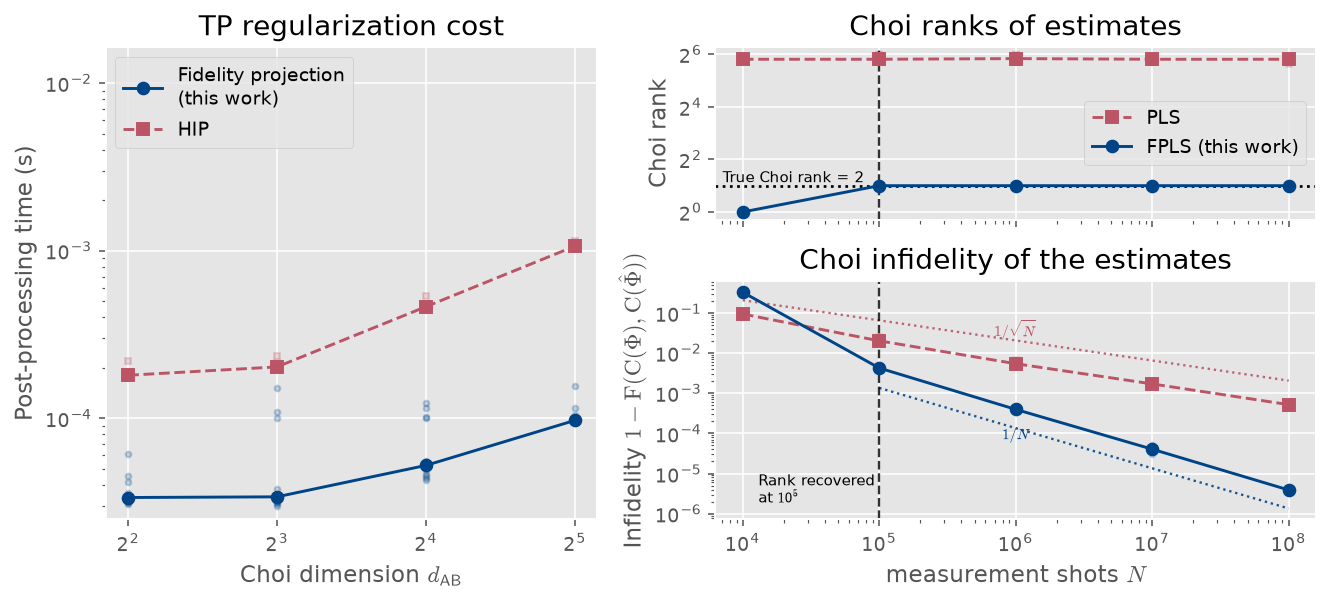

In [7]:
# ---- parameters (reduced: seconds) ------------------------------------------
NQ     = 3                      # qubits per side, so d_AB = 4^NQ
SHOTS  = [1e4, 1e5, 1e6, 1e7, 1e8]
TRIALS = 10                     # trials per shot count
SEED   = 20260817
LADDER_DIMS = (4, 8, 16, 32)    # Choi dimensions timed on the left, or (dA, dB) pairs
LADDER_SDP  = False             # also time the diamond-norm SDP (needs cvxpy)

# ---- paper parameters (about 7 min; with the SDP, several hours): uncomment, and comment out the block above ---
# NQ     = 4                    # d_AB = 256
# SHOTS  = PAPER_SHOTS          # twelve shot counts, 1e4 .. 1e10
# TRIALS = 10
# SEED   = 20260817
# LADDER_DIMS = (4, 8, 16, 32, 64, 128, 256, 512, 1024)
# LADDER_SDP  = True            # the SDP is timed up to d_AB = 128 only
# -----------------------------------------------------------------------------
# A power of two is split as evenly as it allows, so 64 is 8x8 and 128 is 8x16;
# the odd powers are the rectangular points that interleave the square ones.
data   = sweep_headline(nq=NQ, shots=SHOTS, trials=TRIALS, seed=SEED)
ladder = sweep_cost_ladder(dims=LADDER_DIMS, trials=TRIALS, seed=SEED, sdp=LADDER_SDP)
fig_headline(data=data, ladder=ladder);

### Figure 3: rank preservation

Three columns from the **same** density estimate: the estimate itself, then its
two TP regularizations. The fidelity projection is a congruence by an invertible
matrix, so it returns the rank of its input exactly. HIP's TP step and its final
mixing with the maximally mixed state fill in every remaining direction.


rank-2 channel               true rank   2   FPLS   2 (1-F 6.94e-05)   PLS-QPT  12 (1-F 1.46e-03)
amplitude damping, rank 4    true rank   4   FPLS   4 (1-F 6.39e-04)   PLS-QPT  14 (1-F 2.21e-03)


paper: FPLS returns 2 and 4; PLS-QPT returns 209 and 239 of 256


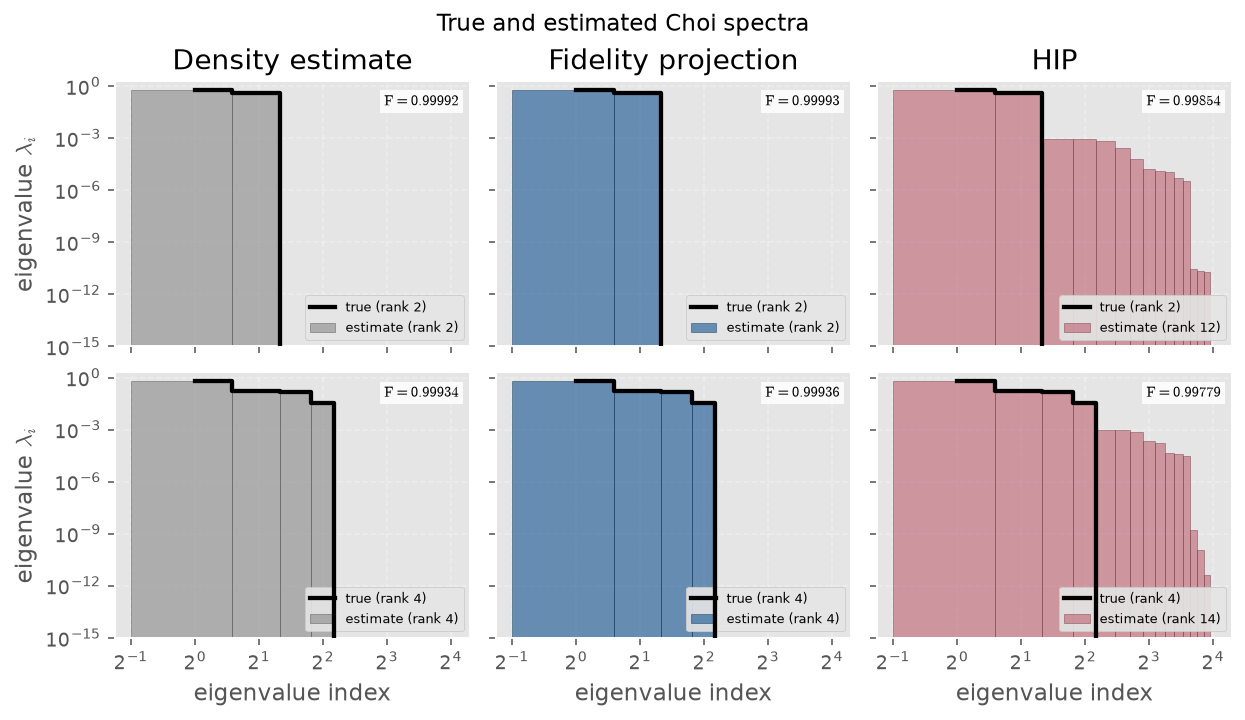

In [8]:
# ---- parameters (reduced: seconds) ------------------------------------------
NQ       = 2                    # d_AB = 4^NQ
N        = 1e6                  # shots
SEED     = 20260817
CHANNELS = (("rank2", "rank-2 channel"),
            ("amp_damping_r2", "amplitude damping, rank 4"))

# ---- paper parameters (about 5 s): uncomment, and comment out the block above ---
# NQ       = 4                  # d_AB = 256
# N        = 1e8
# SEED     = 20260817
# CHANNELS = (("rank2", "rank-2 channel"),
#             ("amp_damping_r2", "amplitude damping, rank 4"))   # damping on 2 of the 4 qubits
# -----------------------------------------------------------------------------
data = sweep_spectra(channels=CHANNELS, nq=NQ, N=N, seed=SEED)
fig_spectra(data=data);

### Table 1: head to head

Infidelity, TP-regularization time and storage, for the two pipelines on the
same data. Storage is that of the returned estimate, as the table counts it:
$r$ Kraus operators for ours against a dense
$d_{\mathsf{AB}} \times d_{\mathsf{AB}}$ matrix for PLS, whose output is of nearly
full rank. The $d_{\mathsf{A}} \times d_{\mathsf{A}}$ workspace the projection
uses while it runs is not counted.


In [9]:
# ---- parameters (reduced: seconds) ------------------------------------------
DIMS   = (16, 64)               # Choi dimensions
N      = 1e6                    # shots
TRIALS = 3
SEED   = 20260817

# ---- paper parameters (about 2.5 min, about 4 GB of memory): uncomment, and comment out the block above ---
# DIMS   = (64, 1024)
# N      = 1e8
# TRIALS = 3
# SEED   = 20260817
# (This recomputes all four rows of the table: the rank-2 channel and a random
#  channel of Choi rank log2(d_AB), on the paper's instances and measurement records.)
# -----------------------------------------------------------------------------
table_head_to_head(data=sweep_table(dims=DIMS, N=N, trials=TRIALS, seed=SEED))

  rank2, d_AB = 16 done                                                       

  rank2, d_AB = 64 done                                                       

  logrank, d_AB = 16 done                                                     

  logrank, d_AB = 64 done                                                     

N = 1e+06, medians over 3 trials, PLS-QPT at its authors' default settings
  d_AB  rank |  1-F (PLS) 1-F (FPLS) |    t (PLS)   t (FPLS)     ratio |  kB (PLS)  kB (FPLS)   ratio
-----------------------------------------------------------------------------------------------------
    16     2 |    1.9e-03    8.1e-05 |      0.3ms      0.08ms        4x |       4.1        0.5      8x
    64     2 |    6.5e-03    4.2e-04 |      7.8ms      0.47ms       16x |      65.5        2.0     32x
    16     4 |    2.2e-03    2.7e-04 |      0.3ms      0.07ms        5x |       4.1        1.0      4x
    64     6 |    1.2e-02    4.2e-03 |      4.5ms      0.49ms        9x |      65.5        6.1     11x

paper Table 1: 8.1e-4 / 4.2e-6 at 2^6 rank 2, 3.6 ms against 0.02 ms, 66 kB against 2 kB;
               4.1e-3 / 1.6e-4 at 2^10 rank 2, 6.9 s against 0.29 ms, 16.8 MB against 33 kB;
               1.2e-2 / 4.6e-3 at 2^10 rank log2(d_AB), 3.7 s against 1.02 ms


### Figure 4: why the iterative method is expensive

Every instance is calibrated to a common distance from the channel set, so
dimension rather than estimate quality is the variable. The point is that it is
not only the cost of an iteration that grows with dimension but the *number* of
them, which is what the fitted exponent measures.


  rank1, d_pu = 0.05: d_A x d_B = 2 x 2                                       

  rank1, d_pu = 0.05: d_A x d_B = 4 x 4                                       

  rank1, d_pu = 0.05: d_A x d_B = 8 x 8                                       

  rank1, d_pu = 0.05: d_A x d_B = 16 x 16                                     

  rank1, d_pu = 0.2: d_A x d_B = 2 x 2                                        

...

  full, d_pu = 0.2: d_A x d_B = 2 x 2                                         

  full, d_pu = 0.2: d_A x d_B = 4 x 4                                         

  full, d_pu = 0.2: d_A x d_B = 8 x 8                                         

  full, d_pu = 0.2: d_A x d_B = 16 x 16                                       

rank1    2.1 d^0.40  1.0 d^0.48
logrank  1.2 d^0.44  1.2 d^0.43
full     1.2 d^0.34  1.1 d^0.49
paper: isometry 1.3 d^0.46, 1.5 d^0.41, 1.3 d^0.41, 1.2 d^0.39; exponents 0.36/0.36/0.40/0.53 and 0.33/0.38/0.49/0.55


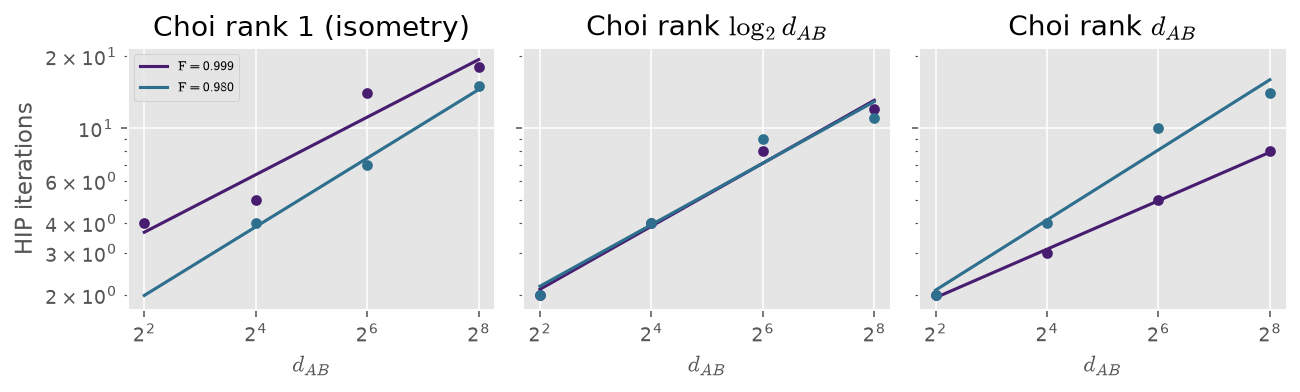

In [10]:
# ---- parameters (reduced: seconds) ------------------------------------------
DIMS    = (4, 16, 64, 256)      # Choi dimensions
TARGETS = (0.05, 0.2)           # purified distances from the channel set
TRIALS  = 3
SEED    = 20260817
FAMILY  = (("rank1", "Choi rank 1 (isometry)"),          # one panel per family
           ("logrank", r"Choi rank $\log_2 d_{AB}$"),
           ("full", r"Choi rank $d_{AB}$"))

# ---- paper parameters (several hours, about 4 GB of memory): uncomment, and comment out the block above ---
# DIMS    = (4, 8, 16, 32, 64, 128, 256, 512, 1024)
# TARGETS = (0.05, 0.1, 0.2, 0.3)
# TRIALS  = 10
# SEED    = 20260817
# FAMILY  = (("rank1", "Choi rank 1 (isometry)"),
#            ("logrank", r"Choi rank $\log_2 d_{AB}$"),
#            ("full", r"Choi rank $d_{AB}$"))
# -----------------------------------------------------------------------------
data = sweep_hip_iterations(dims=DIMS, targets=TARGETS, families=FAMILY,
                            trials=TRIALS, seed=SEED)
fig_hip_iterations(data=data);

### Figure 5: the same estimates in three metrics

Infidelity on the left, trace and Frobenius distance on the right, each between
the Choi states of the true channel and of the estimate. The quadratic gain from
recovering the rank is a property of the **fidelity**: in the two norms all three
pipelines converge at $1/\sqrt{N}$ and differ only by a constant.


  N = 1e4  (1 of 5 shot counts)                                               

  N = 1e5  (2 of 5 shot counts)                                               

  N = 1e6  (3 of 5 shot counts)                                               

  N = 1e7  (4 of 5 shot counts)                                               

  N = 1e8  (5 of 5 shot counts)                                               

onsets: beta_N 1e+05, beta_N/2 1e+04        (paper: 1e6 and 3e5)
  exponent (inf)  FPLS -1.05   PLS-QPT -0.51      (paper: -1.00 and -0.51)
  exponent (tr )  FPLS -0.52   PLS-QPT -0.52      (paper: -0.50 and -0.50)
  exponent (fro)  FPLS -0.52   PLS-QPT -0.52      (paper: -0.50 and -0.50)
  infidelity ratio at N = 1e+06       18.5x
  infidelity ratio at N = 1e+08        210x
  (paper: 6x, 49x, 520x)
  fpls_half  its onset is the first shot count here, so there is no pre-onset point   (paper: 4.9x at beta_N/2, 10.5x at beta_N)
  fpls_beta  behind PLS-QPT by 5.8x at the last N before its onset   (paper: 4.9x at beta_N/2, 10.5x at beta_N)
  at N = 1e+08 ahead by 1.1x in trace and 1.0x in Frobenius   (paper: 1.2x, 1.1x)
  before its onset beta_N/2 is behind by up to n/a in trace and n/a in Frobenius   (paper: 2.2x, 3.3x)


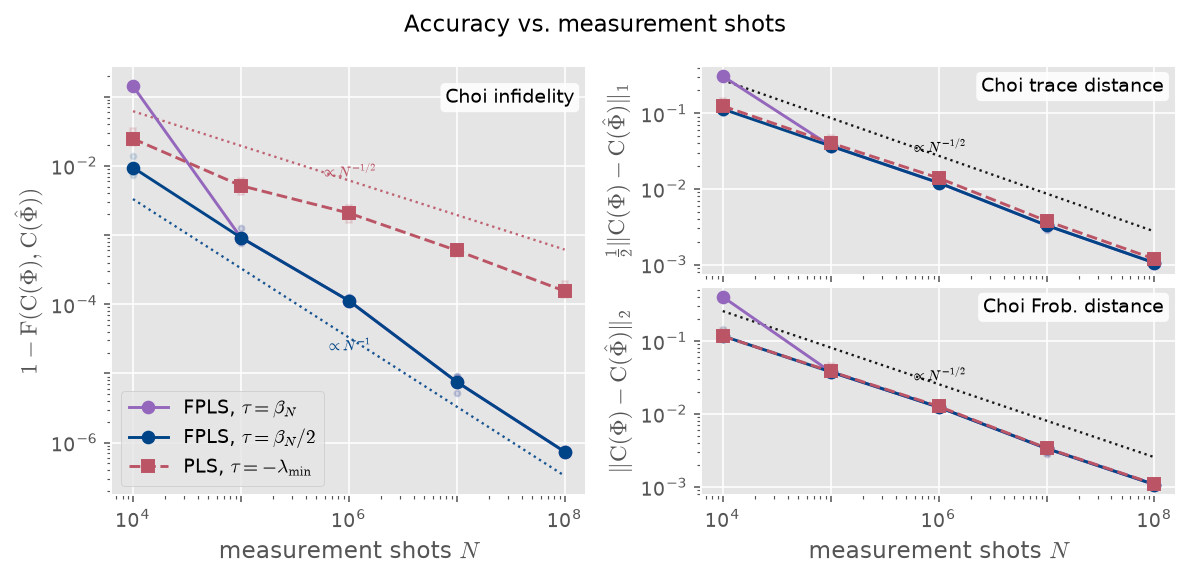

In [11]:
# ---- parameters (reduced: seconds) ------------------------------------------
NQ     = 2                      # d_AB = 4^NQ
SHOTS  = [1e4, 1e5, 1e6, 1e7, 1e8]
TRIALS = 3
SEED   = 20260817

# ---- paper parameters (about 3 min): uncomment, and comment out the block above ---
# NQ     = 4                    # d_AB = 256
# SHOTS  = PAPER_SHOTS          # twelve shot counts, 1e4 .. 1e10
# TRIALS = 10
# SEED   = 20260817
# -----------------------------------------------------------------------------
data = sweep_accuracy(nq=NQ, shots=SHOTS, trials=TRIALS, seed=SEED)
fig_accuracy(data=data);

### Figure 6: across channels of low Choi rank

The onset moves with the smallest nonzero Choi eigenvalue, as the analysis
predicts: the Werner-Holevo channel has rank 28 but a flat spectrum, so it
recovers two decades before rank-8 amplitude damping. The paper's version has
two further rows showing the spectra at $N = 10^6$ and $10^{10}$; recomputed
here, the figure carries the rank and accuracy rows.


  N = 1e4  (1 of 5 shot counts)                                               

  N = 1e5  (2 of 5 shot counts)                                               

  N = 1e6  (3 of 5 shot counts)                                               

  N = 1e7  (4 of 5 shot counts)                                               

  N = 1e8  (5 of 5 shot counts)                                               

...

  N = 1e6  (3 of 5 shot counts)                                               

  N = 1e7  (4 of 5 shot counts)                                               

  N = 1e8  (5 of 5 shot counts)                                               

amp. damping, rank 2       true rank   2   onset       1e+05   PLS-QPT modal rank 12-13 (per trial 11-15) of 16   exponents -1.0 / -0.5
amp. damping, rank 4       true rank   4   onset       1e+06   PLS-QPT modal rank 12-15 (per trial 12-15) of 16   exponents -1.0 / -0.5
Werner--Holevo             true rank   6   onset       1e+05   PLS-QPT modal rank 14-15 (per trial 14-15) of 16   exponents -1.0 / -0.6


paper: onsets 3e5, 1e7, 1e9, 1e7; PLS-QPT 48-63 of 64 per trial; exponents -1.0 against -0.5 to -0.7


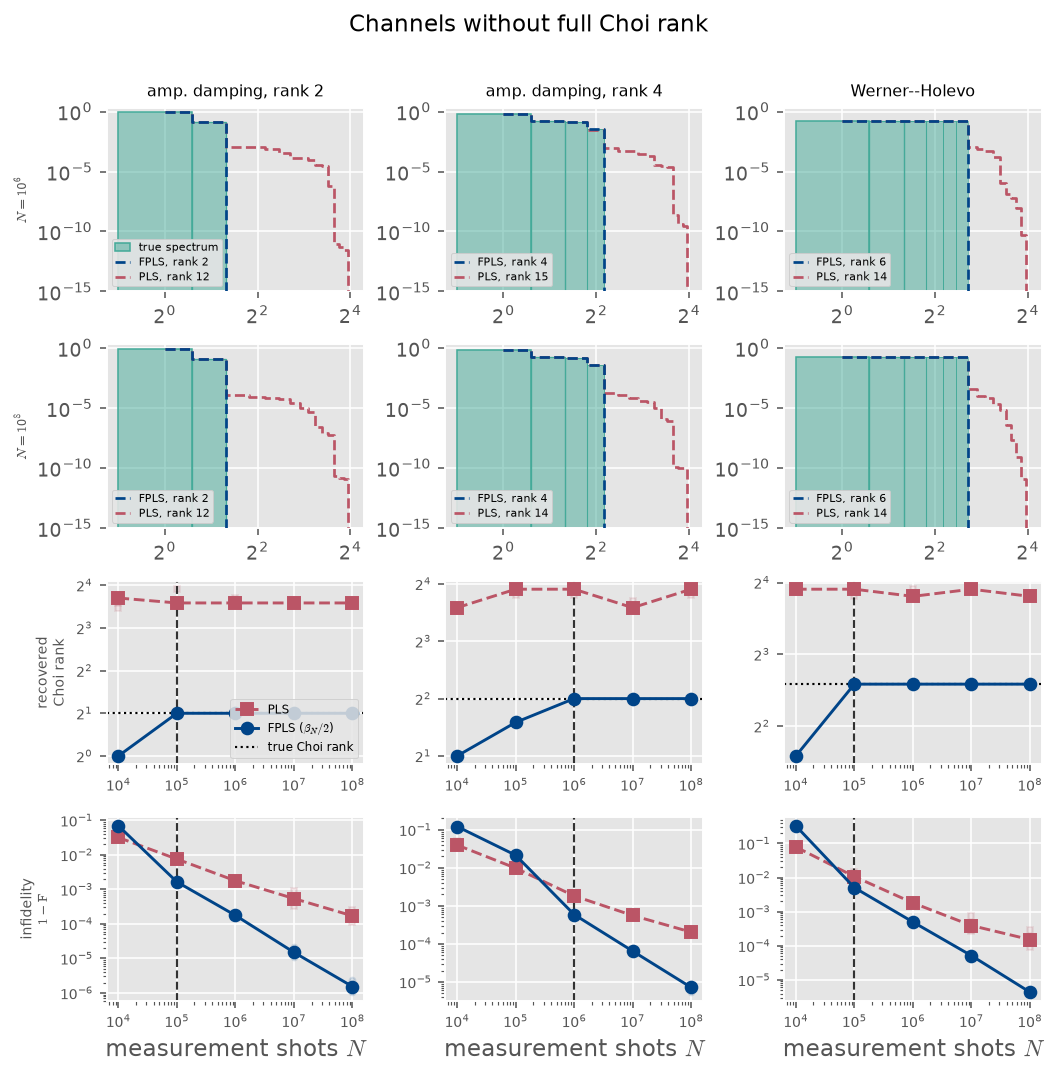

In [12]:
# ---- parameters (reduced: seconds) ------------------------------------------
NQ       = 2                    # d_AB = 4^NQ
SHOTS    = [1e4, 1e5, 1e6, 1e7, 1e8]
TRIALS   = 3
SEED     = 20260817
SPECTRA  = (1e6, 1e8)           # shot counts of the two spectra rows
CHANNELS = (("amp_damping_r1", "amp. damping, rank 2"),
            ("amp_damping_r2", "amp. damping, rank 4"),
            ("werner_holevo",  "Werner--Holevo"))

# ---- paper parameters (about 20 s): uncomment, and comment out the block above ---
# NQ       = 3                  # d_AB = 64
# SHOTS    = PAPER_SHOTS        # twelve shot counts, 1e4 .. 1e10
# TRIALS   = 10
# SEED     = 20260817
# SPECTRA  = (1e6, 1e10)
# CHANNELS = (("amp_damping_r1", "amp. damping, rank 2"),
#             ("amp_damping_r2", "amp. damping, rank 4"),
#             ("amp_damping_r3", "amp. damping, rank 8"),
#             ("werner_holevo",  "Werner--Holevo, rank 28"))
# -----------------------------------------------------------------------------
data = sweep_robustness(CHANNELS, nq=NQ, shots=SHOTS, trials=TRIALS, seed=SEED,
                        spectra_at=SPECTRA)
fig_channel_robustness(data=data);

### Figure 7: where this estimator loses

At full Choi rank there is no gap to place a threshold in, so the Bernstein rule
admits a direction only once the data resolves it, and the returned rank climbs
with $N$ without reaching the truth. PLS, which keeps every direction, is the
better estimator here. The figure is in the paper for that reason.


  N = 1e4  (1 of 5 shot counts)                                               

  N = 1e5  (2 of 5 shot counts)                                               

  N = 1e6  (3 of 5 shot counts)                                               

  N = 1e7  (4 of 5 shot counts)                                               

  N = 1e8  (5 of 5 shot counts)                                               

...

  N = 1e7  (4 of 5 shot counts)                                               

  N = 1e8  (5 of 5 shot counts)                                               

depolarizing, $p=0.05$     true rank  16   onset       1e+08   PLS-QPT modal rank 12-15 (per trial 12-15) of 16   exponents -0.2 / -0.1
QFT + 3% depol.            true rank  16   onset not reached   PLS-QPT modal rank 13-15 (per trial 13-15) of 16   exponents -0.1 / -0.2


/Users/afham/Projects/fidelity_QPT/fplsplots.py:99: RankWarning: Polyfit may be poorly conditioned
  return float(np.polyfit(np.log10(x[m]), np.log10(y[m]), 1)[0])
/Users/afham/Projects/fidelity_QPT/fplsplots.py:99: RankWarning: Polyfit may be poorly conditioned
  return float(np.polyfit(np.log10(x[m]), np.log10(y[m]), 1)[0])


paper: no FPLS onset within N <= 1e10; PLS-QPT ranks 48 to 63 of 64


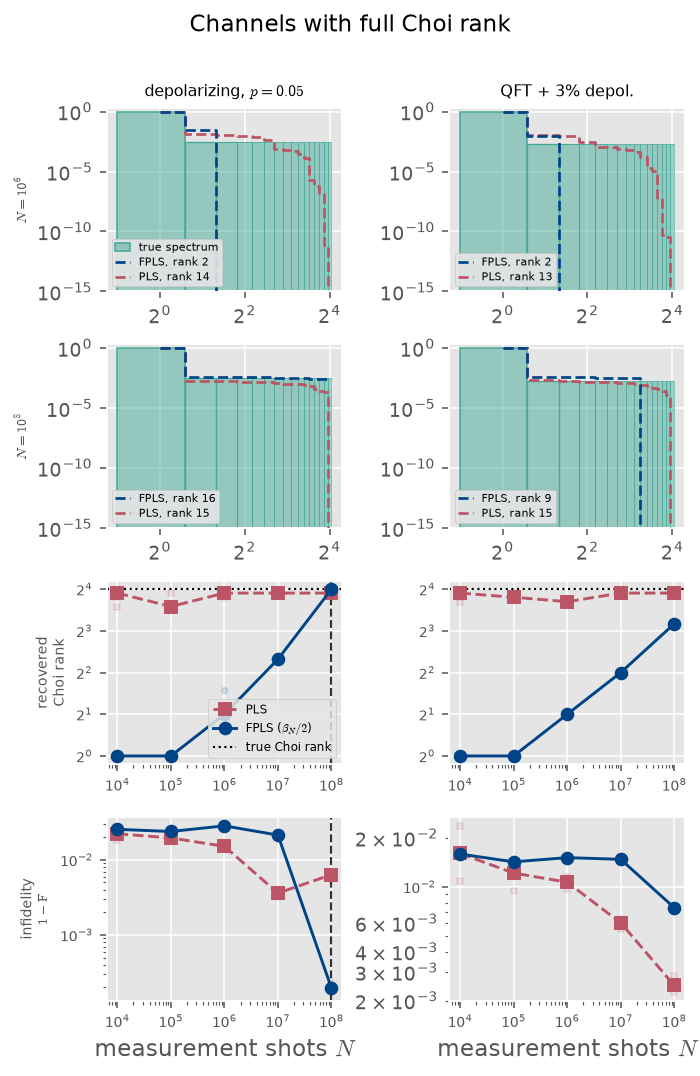

In [13]:
# ---- parameters (reduced: seconds) ------------------------------------------
NQ       = 2                    # d_AB = 4^NQ
SHOTS    = [1e4, 1e5, 1e6, 1e7, 1e8]
TRIALS   = 3
SEED     = 20260817
SPECTRA  = (1e6, 1e8)           # shot counts of the two spectra rows
CHANNELS = (("depolarizing_p5",  "depolarizing, $p=0.05$"),
            ("qft_depol_p3",     "QFT + 3% depol."))

# ---- paper parameters (about 10 s): uncomment, and comment out the block above ---
# NQ       = 3                  # d_AB = 64
# SHOTS    = PAPER_SHOTS        # twelve shot counts, 1e4 .. 1e10
# TRIALS   = 10
# SEED     = 20260817
# SPECTRA  = (1e6, 1e10)
# CHANNELS = (("depolarizing_p5",  "depolarizing, $p=0.05$"),
#             ("qft_depol_p3",     "QFT + 3% depol."))
# (These are two of the paper's four columns. The other two, 5% depolarizing on each
#  qubit and the QFT mixed with a random channel, are in data/fullrank.json: call
#  fig_fullrank_tradeoff() with no argument to draw all four.)
# -----------------------------------------------------------------------------
data = sweep_robustness(CHANNELS, nq=NQ, shots=SHOTS, trials=TRIALS, seed=SEED,
                        spectra_at=SPECTRA)
fig_fullrank_tradeoff(data=data);

### Figure 8: the threshold rules

This one needs nothing cached: all four curves are the same thresholded
estimator followed by the same fidelity projection, so they differ only in
$\tau$. $\tau = 0$ keeps every positive noise eigenvalue; $\tau = -\lambda_{\min}$
compares two order statistics of the same noise and recovers the rank in about
half the trials at every $N$, so its accuracy is drawn as one median **per
branch**; the Bernstein thresholds sit above the noise and are exact past their
onset.


  N = 1e4  (1 of 5 shot counts)                                               

  N = 1e5  (2 of 5 shot counts)                                               

  N = 1e6  (3 of 5 shot counts)                                               

  N = 1e7  (4 of 5 shot counts)                                               

  N = 1e8  (5 of 5 shot counts)                                               

...

  N = 1e6  (3 of 5 shot counts)                                               

  N = 1e7  (4 of 5 shot counts)                                               

  N = 1e8  (5 of 5 shot counts)                                               

amp_damping_r2, $d_{AB} = 16$
   lambda_r = 0.036;  guaranteed onset beta_N < lambda_r/2 at N = 4e+06
   tau = 0        modal rank climbs 7 -> 8 of 16
   tau = -lmin    modal rank 4-4, exact in 2-3 of 3 trials at every N >= 1e5, with no trend
   tau = beta_N   exact from N = 1e+06;  beta_N/2 from N = 1e+06
rank2, $d_{AB} = 16$
   lambda_r = 0.244;  guaranteed onset beta_N < lambda_r/2 at N = 8e+04
   tau = 0        modal rank climbs 6 -> 6 of 16
   tau = -lmin    modal rank 3-4, exact in 0-1 of 3 trials at every N >= 1e5, with no trend
   tau = beta_N   exact from N = 1e+05;  beta_N/2 from N = 1e+04


paper: 6->15 of 64 and 7->18 of 256 at tau = 0; modal rank 4-5 and 2-3 and exact in 3-9 of 10 trials at -lambda_min;
       onsets 3e7 and 1e6 (halved: 1e7 and 3e5), guaranteed onsets 6e7 and 3e6


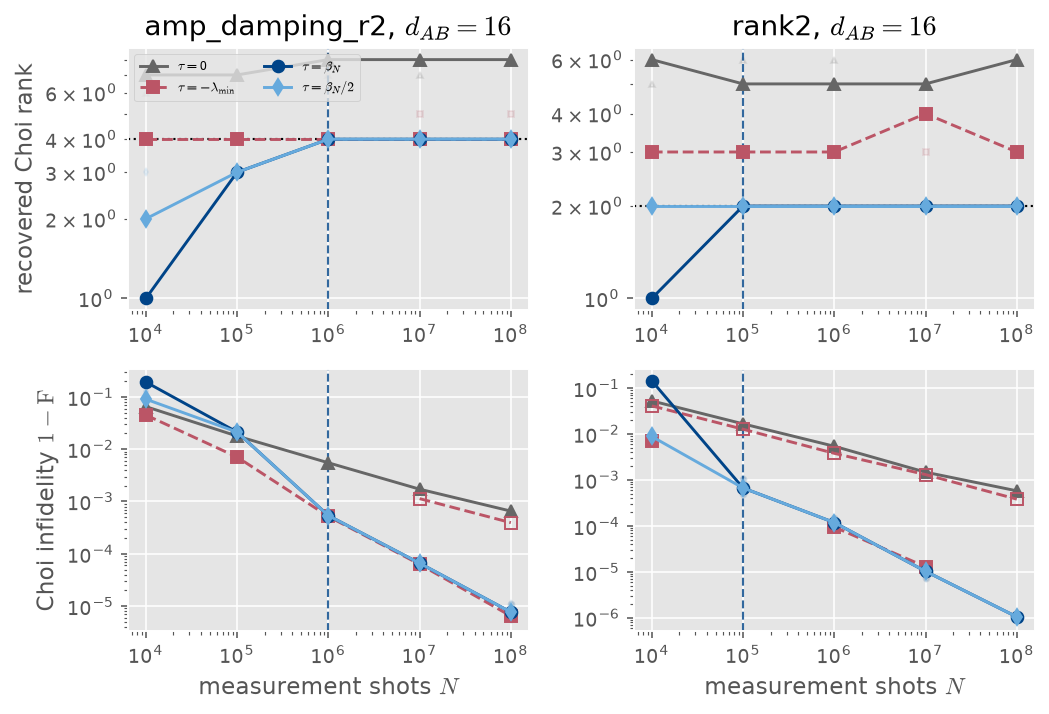

In [14]:
# ---- parameters (reduced: seconds) ------------------------------------------
NQ       = 2                    # d_AB = 4^NQ, for every channel that does not set its own
SHOTS    = [1e4, 1e5, 1e6, 1e7, 1e8]
TRIALS   = 3
SEED     = 20260817
CHANNELS = (("amp_damping_r2", None), ("rank2", None))

# ---- paper parameters (about 1 min): uncomment, and comment out the block above ---
# NQ       = 3
# SHOTS    = [1e3] + PAPER_SHOTS    # thirteen shot counts, 1e3 .. 1e10
# TRIALS   = 10
# SEED     = 20260817
# CHANNELS = (("amp_damping_r2", None, 3),    # a third entry is that channel's own NQ:
#             ("rank2", None, 4))             # d_AB = 64 (rank 4) and d_AB = 256 (rank 2)
# -----------------------------------------------------------------------------
data = sweep_thresholds(channels=CHANNELS, nq=NQ, shots=SHOTS, trials=TRIALS, seed=SEED)
fig_threshold_strategies(data=data);

## 3. The implementation on a worked example

Theorem 1 is proved in the paper; this cell checks that the library implements it as stated. For a fixed bipartite state, written out explicitly, the projection is recomputed from the formula with inline NumPy and compared with `fidelity_projection`, the only function imported here; its optimal value is compared with the closed form; the certificate used in the proof is evaluated; and the stability constants of the theorem are measured on random instances, where they sit well inside the proved bounds.

The statement: for $\rho$ with invertible input marginal $\rho_{\mathsf A}$,
$$\Pi_{\mathcal C}(\rho) \;=\; \operatorname*{argmax}_{\sigma \in \mathcal C_{\mathsf{A},\mathsf{B}}} \mathrm{F}(\rho, \sigma) \;=\; \mathrm{N}_{\mathsf A}(\rho), \qquad \max_{\sigma \in \mathcal C_{\mathsf{A},\mathsf{B}}} \mathrm{F}(\rho,\sigma) \;=\; \frac{\operatorname{Tr}\sqrt{\rho_{\mathsf A}}}{\sqrt{d_{\mathsf A}}},$$
and the projection loses at most a factor 2 in Bures distance, equivalently 4 in infidelity.

In [15]:
import numpy as np
from fpls import fidelity_projection          # the only import; the primitives below are written inline

dA = dB = 2

# a fixed rank-2 state on A (x) B: V V^dag, normalised
V = np.array([[0.80 + 0.00j, 0.10 + 0.00j],
              [0.20 + 0.30j, -0.50 + 0.00j],
              [0.00 + 0.00j, 0.60 + 0.10j],
              [0.40 + 0.00j, 0.30 - 0.20j]])
rho = V @ V.conj().T
rho = rho / np.trace(rho).real

# --- inline primitives -----------------------------------------------------
def sqrtm_psd(P):
    w, U = np.linalg.eigh((P + P.conj().T) / 2)
    return (U * np.sqrt(np.maximum(w, 0))) @ U.conj().T

def F(P, Q):                                   # root fidelity ||sqrt(P) sqrt(Q)||_1
    return float(np.sum(np.linalg.svd(sqrtm_psd(P) @ sqrtm_psd(Q), compute_uv=False)))

def marginal_A(P):                             # Tr_B
    return np.trace(P.reshape(dA, dB, dA, dB), axis1=1, axis2=3)

def inv_sqrtm_psd(P):
    w, U = np.linalg.eigh((P + P.conj().T) / 2)
    return (U * np.where(w > 1e-12, 1 / np.sqrt(np.maximum(w, 1e-300)), 0.0)) @ U.conj().T

rho_A = marginal_A(rho)

# --- 1. the library implements the formula of the paper --------------------
M = np.kron(inv_sqrtm_psd(rho_A), np.eye(dB))
N_A = (M @ rho @ M.conj().T) / dA
print(f"library vs formula, max |difference|  {np.abs(N_A - fidelity_projection(rho, dA)).max():.2e}   (paper: Eq. 4)")

# --- 2. the output is the Choi state of a channel --------------------------
marg_err = np.abs(marginal_A(N_A) - np.eye(dA) / dA).max()
print(f"marginal error of the output          {marg_err:.2e}   (I_A/d_A up to roundoff)")
print(f"smallest eigenvalue of the output     {np.linalg.eigvalsh(N_A).min():+.2e}   (PSD up to roundoff)")
print(f"trace of the output                   {np.trace(N_A).real:.12f}")

# --- 3. the optimal value is a function of the marginal alone --------------
opt_formula = float(np.sum(np.sqrt(np.maximum(np.linalg.eigvalsh(rho_A), 0))) / np.sqrt(dA))
print(f"F(rho, N_A(rho))                      {F(rho, N_A):.12f}")
print(f"Tr sqrt(rho_A) / sqrt(d_A)            {opt_formula:.12f}   (paper: Eq. 46)")

# --- 4. the certificate of the proof, evaluated on this instance -----------
# With H = (rho_A^{-1/2} (x) I)/sqrt(d_A), the matrix AM-GM inequality gives
#     F(rho, sigma) <= (Tr[rho H] + Tr[sigma H^{-1}])/2   for every channel sigma,
# and both terms equal Tr sqrt(rho_A)/sqrt(d_A), so the bound is attained by N_A(rho).
rng = np.random.default_rng(0)
def random_channel():
    X = rng.standard_normal((dA * dB, dA * dB)) + 1j * rng.standard_normal((dA * dB, dA * dB))
    P = X @ X.conj().T
    Mx = np.kron(inv_sqrtm_psd(marginal_A(P)), np.eye(dB))
    return (Mx @ P @ Mx.conj().T) / dA

H = np.kron(inv_sqrtm_psd(rho_A), np.eye(dB)) / np.sqrt(dA)
H_inv = np.kron(sqrtm_psd(rho_A), np.eye(dB)) * np.sqrt(dA)
sig = random_channel()
print(f"Tr[rho H]                             {np.trace(rho @ H).real:.12f}")
print(f"Tr[sigma H^-1], sigma a random channel {np.trace(sig @ H_inv).real:.12f}   (the same for every channel)")

# --- 5. rank preservation and the stability constants ----------------------
rank = lambda P: int((np.linalg.eigvalsh(P) > 1e-10).sum())
bures = lambda P, Q: np.sqrt(max(0.0, 2 - 2 * F(P, Q)))
worst_bures, worst_infid = 0.0, 0.0
for _ in range(2000):
    true = random_channel()                     # a channel
    X = rng.standard_normal((dA * dB, 2)) + 1j * rng.standard_normal((dA * dB, 2))
    est = X @ X.conj().T
    est = est / np.trace(est).real              # a bipartite state, not a channel
    proj = fidelity_projection(est, dA)
    if bures(true, est) > 1e-9:
        worst_bures = max(worst_bures, bures(true, proj) / bures(true, est))
        worst_infid = max(worst_infid, (1 - F(true, proj)) / (1 - F(true, est)))
print(f"rank(N_A(rho)) = rank(rho)            {rank(N_A)} = {rank(rho)}")
print(f"largest Bures ratio over 2000 pairs   {worst_bures:.4f}        (theorem: at most 2)")
print(f"largest infidelity ratio              {worst_infid:.4f}        (theorem: at most 4)")

# --- assertions ------------------------------------------------------------
assert np.abs(N_A - fidelity_projection(rho, dA)).max() < 1e-12
assert marg_err < 1e-12 and np.linalg.eigvalsh(N_A).min() > -1e-12
assert abs(np.trace(N_A).real - 1) < 1e-12
assert abs(F(rho, N_A) - opt_formula) < 1e-12
assert abs(np.trace(rho @ H).real - opt_formula) < 1e-12
assert abs(np.trace(sig @ H_inv).real - opt_formula) < 1e-12
assert rank(N_A) == rank(rho)
assert worst_bures <= 2 + 1e-9 and worst_infid <= 4 + 1e-9
print("\nall checks passed")

library vs formula, max |difference|  0.00e+00   (paper: Eq. 4)
marginal error of the output          3.33e-16   (I_A/d_A up to roundoff)
smallest eigenvalue of the output     -9.84e-18   (PSD up to roundoff)
trace of the output                   1.000000000000
F(rho, N_A(rho))                      0.993880254780
Tr sqrt(rho_A) / sqrt(d_A)            0.993880254780   (paper: Eq. 46)
Tr[rho H]                             0.993880254780
Tr[sigma H^-1], sigma a random channel 0.993880254780   (the same for every channel)
rank(N_A(rho)) = rank(rho)            2 = 2
largest Bures ratio over 2000 pairs   1.1558        (theorem: at most 2)
largest infidelity ratio              1.3359        (theorem: at most 4)

all checks passed
